# Assignment 2               
## Muhammad Ullah 400529222

### Problem 1: Inferential Statistics and Univariate Data [40 points/100 points]
You are a biomedical engineer validating the performance of a clinical physiological measurement device used in patient monitoring. Manufacturers report nominal population values for physiological variables under standardized conditions, and you must verify that observed measurements are consistent with those claims while accounting for measurement noise and biological variability. In this problem, you will simulate a clinical measurement study, evaluate distributional assumptions, perform a one-sample hypothesis test, and interpret results in a biomedical context of your choosing. Your submission will be a 1–2 page report-style PDF presenting your analysis, including supporting plots. Also submit the pdf and Python code file

**a) Choose a physiological variable and reference value**


The variable that has been chosen is the core body temperature of a human body. The nominal mean value, which is μ₀, is 37.0 with unit of degree celsius (°C). The reason why this variable is clinically important and why validating measurement accuracy matters in biomedical engineering is because this variable is significant for thermoregulation & infection screening. Thermoregulation is a process by which is done from the nervous system, specifically the hypothalamus, that maintains the body temperature at a set point of around 37 degree celsius. Maintaining this temperature is important as it allows for enzymatic reactions and metabolic stability to occur in the body. The body being slightly hot will allow the proteins and enzymes to denature, which will not allow the biological catalysts to speed up chemical reactions inside the body, for example metabolism. Slightly cold will allow the preteins and enzymes to slow down its process to create vital means for the body to use. Additionally, 37 degree celsius gives a baseline for screening purposes, anything lower or higher poses significant risk for individuals. In this case, the situation is related to infection screening and being able to capture a infection before it is too late. Infections trigger the release of pyrogens, which resets the hypothalamic thermostat to a much higher level. This mechanism results in an individual going into a fever. Fever is a primary use of screening and a primary symptom of which the body overheats itself to remove the infection. High-percision monitoring allows clinicians to determine if a fever is a therapeutic response or if it has reached dangerous levels of hyperpyrexia (high fever) [1].

[1]E. V. Osilla, J. L. Marsidi, K. R. Shumway, and S. Sharma, “Physiology, temperature regulation,” National Library of Medicine, 2023. https://www.ncbi.nlm.nih.gov/books/NBK507838/
‌

**b) Model setup (choose and discuss your model and assumptions)**

For the model setup, since the device will is simply used as a screening tool, a higher variability is realistic for testing (screening, wearable, or field measurement). A higher variability would correspond to a value of around 0.5 degree celsius. In a screening scenario, the variance is realistic because the body temperature varies and fluctuates throughout the day. Typically, the lowest body temperature occurs at 4 AM, and the highest body temperature occurs at 6 PM[1]. In a mass screening, patients may arrive at different times for each independent screening test. Additionally, different parts of the body have different temperature variance, e.g axillary temperatures are roughly lower than oral or nasal area. Lastly, tools are subjected to surface noise, for example blood vessels dilating, sweat, temperature of the room, and many more.
Next, the value of n will be 50, as a sample of 50 ensures that the distribution of the sample mean will be approximately normal. For practical contraints, the cost will be significant as the test is dealing with 50 individuals. However in terms of patient burdan and time, it will be significantly less as firstly the device will be non-invasive and additionally it will take test on the surface layer/skin. Once the device is on the patient, it will immediately read the values of the temperature. Since the feasibility is roughly medium (more patient but device is less costly for each screening), the precision would also be mediocre (more patient but again high variance for the device screening).

**c) Simulate a clinical study (the “observed” dataset sample)**

Generate and show data modeled using X~N(μ0, 𝜎 2) to simulate data representing observations from n independent adult patients, using Python and a random number generator seed of rng=2026 for reproducibility. You can show the data as a boxplot or histogram

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

Text(0, 0.5, 'Frequency')

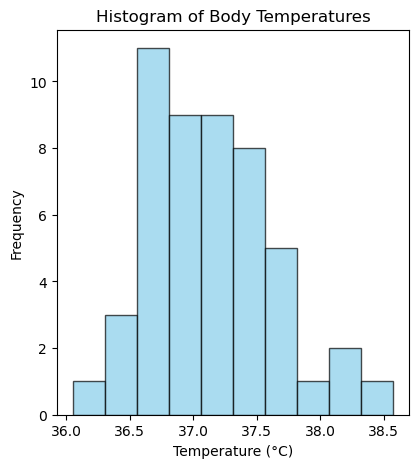

In [52]:
mu_0 = 37.0
sigma = 0.5
n = 50
rng = np.random.default_rng(2026)
data = rng.normal(mu_0, sigma, n)

sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(data, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Histogram of Body Temperatures')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')


Using Python, state the sample mean and sample standard deviation

In [53]:
print(f"Sample Mean: {sample_mean}")
print(f"Sample Std Dev: {sample_std}")

Sample Mean: 37.108539284487364
Sample Std Dev: 0.5077027486026175


You are given that the data come from a reasonably normal population, so you can assume this to be true. Choose and defend a statistical test to test whether your study’s’ sample mean equals the μ0 value (explain why the test is appropriate for your data and defend the assumptions for a two-sided, one-sample t-test)

The most appropriate test for this study is the two-sided, one-sample t-test. It is assumed for the study that each of the 50 measurements comes from a different patient, ensuring the data points are not correlated or have any sort of directionality associated to it. Futhermore, the study uses a two-sided test for the interest in any significant deviation from the nominal value either hypothermia (lower than 37.0) or fever (higher than 37.0). The reason for using the t-test is because, since we are able to use the z-test (as variance is known), the t-test used instead for sample size greater than n=30 or 40. 

**d) Hypothesis test: Using α = 0.05**

Testing whether the true mean temperature of the population from which our sample was drawn is equal to the nominal clinical value. Null Hypothesis (H0): μ = 37.0 degree celsius,t he true population mean is equal to the nominal clinical value. Alternative Hypothesis (Ha): μ /= 37 degree celsius, the true population mean is significantly different from the nominal clinical value.

In [17]:
numerator = sample_mean - mu_0
denominator = sample_std / np.sqrt(n)
t_stat = numerator / denominator
print(t_stat)

1.5116889616491456


In [18]:
p_value = 2 * stats.t.sf(np.abs(t_stat), df=n-1)
print(p_value)

0.1370360265114966


Since the p-value of 0.137 is greater than the significance level of α = 0.05, the test fail to reject the null hypothesis H0. There is not enough statistical evidence to suggest that the mean temperature of our sample differs significantly from 37 degree celsius. The observed measurements are consistent with the nominal clinical value. Although the sample mean looks like is is slightly higher than 37 degree celsius, it still lies within the expected range of sampling error given our chosen variability 0.5. Since we fail to reject the null hypothesis, the device demonstrated high accuracy, as the sample mean was not statistically different from the clinical reference of 37 degree celsius. This suggests the device is correctly calibrated. However, given the observed standard deviation of 0.5, the device may require multiple readings or better environmental controls to improve individual precision for infection screening.

**e) Confidence intervals:**

In [54]:
se = sample_std / np.sqrt(n)
confidence_level = 0.95
df = n - 1 
t_critical = stats.t.ppf((1 + confidence_level) / 2, df)
margin_of_error = t_critical * se
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"95% CI Lower Bound: {ci_lower}")
print(f"95% CI Upper Bound: {ci_upper}")

95% CI Lower Bound: 36.96425175980796
95% CI Upper Bound: 37.25282680916677


Based on this study, it is 95% confident that the true average core body temperature of the population measured by this device lies between 36.9643°C and 37.2528°C. This range is narrow which suggesting that while individual patients vary, our estimate of the patient temperature is quite precise. The nominal clinical value of 37°C falls within the 95% confidence interval (36.964 < 37.0 < 37.253). This demonstrates that the device's average performance is aligned with standards. The tight span of the interval provides strong evidence for the device's reliability as a population screening tool, though individual variability remains a factor to be managed through clinical protocols.

### Problem 2: [30 points/100 points] Independent T-tests

Resting heart rate (HR) is an important physiological
indicator of cardiovascular and autonomic function. Wearable
devices are increasingly used to estimate resting heart rate, but
different signal-processing algorithms may yield slightly different
measurements.
In a validation study, resting heart rate (beats/min) was recorded
for two independent groups of healthy adults, each measured using
a different wearable algorithm under standardized resting
conditions.
• Algorithm A: baseline manufacturer algorithm
• Algorithm B: updated algorithm with enhanced noise filtering
A higher heart rate indicates higher estimated cardiac activity.
Is there evidence to support the claim that Algorithm B produces a
different mean resting heart rate estimate than Algorithm A?
Use α = 0.05

Algorithm A: 71.8, 70.2,71.4,70.6,71.9,72.1,70.0,70.5,72.0,70.7,72.2,70.4,70.3,70.6,71.2,71.6,72.1

Algorithm B: 72.8,73.8,73.2,73.0,72.8,72.7,72.5,72.2,72.0,71.8,71.6,71.7,71.9,72.1,NaN,NaN,NaN 

**a) Model and test selection; Exploratory Data Analysis**

In [21]:
A = pd.Series([71.8, 70.2,71.4,70.6,71.9,72.1,70.0,70.5,72.0,70.7,72.2,70.4,70.3,70.6,71.2,71.6,72.1], name="AlgorithmA")
B = pd.Series([72.8,73.8,73.2,73.0,72.8,72.7,72.5,72.2,72.0,71.8,71.6,71.7,71.9,72.1], name="AlgorithmB")
df = pd.concat([A, B], axis="columns")
df

,AlgorithmA,AlgorithmB
0,71.8,72.8
1,70.2,73.8
2,71.4,73.2
3,70.6,73.0
4,71.9,72.8
5,72.1,72.7
6,70.0,72.5
7,70.5,72.2
8,72.0,72.0
9,70.7,71.8


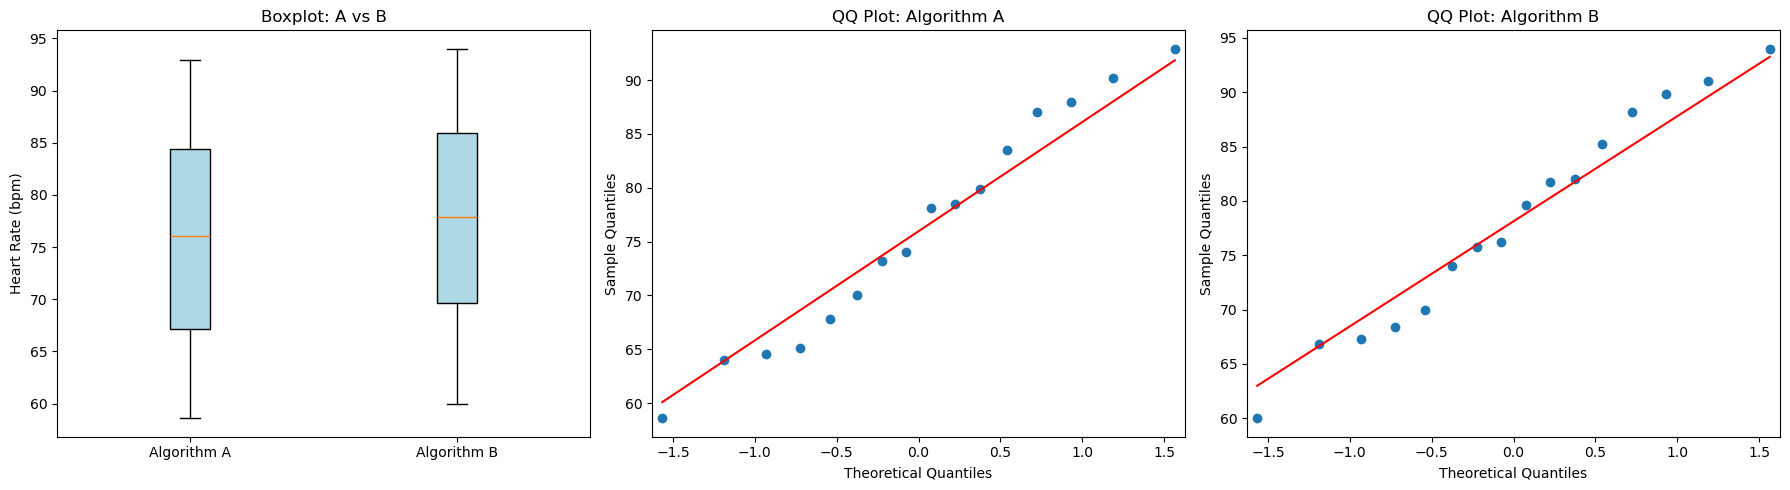

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].boxplot([A, B], tick_labels=['Algorithm A', 'Algorithm B'], patch_artist=True, 
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Boxplot: A vs B')
axes[0].set_ylabel('Heart Rate (bpm)')

sm.qqplot(A, line='s', ax=axes[1])
axes[1].set_title('QQ Plot: Algorithm A')

sm.qqplot(B, line='s', ax=axes[2])
axes[2].set_title('QQ Plot: Algorithm B')

plt.tight_layout()
plt.show()

In [57]:
n_A = len(A)
mean_A = A.mean()
std_A = A.std(ddof=1)
jb_A = (n_A / 6) * (skew_A**2 + (kurt_A - 3)**2 / 4)

n_B = len(B)
mean_B = B.mean()
std_B = B.std(ddof=1)
jb_B = (n_B / 6) * (skew_B**2 + (kurt_B - 3)**2 / 4)

f_stat = (std_A**2) / (std_B**2)
dfn, dfd = n_A - 1, n_B - 1
f_critical = stats.f.ppf(1 - 0.025, dfn, dfd) 
p_f = 2 * (1 - stats.f.cdf(f_stat, dfn, dfd))

t_stat, p_t = stats.ttest_ind(A, B, equal_var=True)

print(f"Algorithm A: n={n_A}, x̄={mean_A}, s={std_A}, JB_A = {jb_A}")
print(f"Algorithm B: n={n_B}, x̄={mean_B}, s={std_B}, JB_B = {jb_B}")
print(f"F-statistic = {f_stat}, F-critical (0.025) = {f_critical}")
print(f"T-statistic = {t_stat}, T-test p-value = {p_t}")

Algorithm A: n=16, x̄=75.9625, s=10.472050101739075, JB_A = 1.6742822474530685
Algorithm B: n=16, x̄=78.125, s=9.987625677140022, JB_B = 0.957592575725315
F-statistic = 1.0993574106623718, F-critical (0.025) = 2.8620925304635048
T-statistic = -0.5977377149534188, T-test p-value = 0.5545006804827461


Since our F-statistic is less than this critical F-value, we fail to reject the null hypothesis. This test is a two-sample, unpaired as it comparing two independent groups of adults. It is parametric due to the JB and equal variance (F-test) are met. Lastly, it is also two-sided as it is testing for any difference μA and μB between the algorithms.

**b) Test**

By Hand:

Pooled Estimator of Variance

s_p = sqrt [ ((n_A−1)s_A² + (n_B−1)s_B²) / (n_A + n_B − 2)]

= sqrt( ((16)(0.7755²) + (13)(0.6440²)) / (29) )

= 0.7195

Standard Error

SE = s_p * sqrt(1/n_A + 1/n_B)

= 0.7195 * sqrt(1/17 + 1/14)

= 0.2597

T Statistic

t = (x̄_B − x̄_A) / SE

=1.2828 / 0.2597 

=4.939

t-critical = t_(0.975, 29) = 2.045

p-value for 2-sided test at df=29: 2* (less than 0.0005) < 0.001

critical value method: t-statistic > t-critical so reject null hypothesis


By Python:

In [68]:
A = pd.Series([71.8, 70.2, 71.4, 70.6, 71.9, 72.1, 70.0, 70.5, 72.0, 70.7, 72.2, 70.4, 70.3, 70.6, 71.2, 71.6, 72.1])
B = pd.Series([72.8, 73.8, 73.2, 73.0, 72.8, 72.7, 72.5, 72.2, 72.0, 71.8, 71.6, 71.7, 71.9, 72.1, np.nan, np.nan, np.nan])
A_clean = A.dropna()
B_clean = B.dropna()

n_A, n_B = len(A_clean), len(B_clean)
mean_A, mean_B = A_clean.mean(), B_clean.mean()
var_A, var_B = A_clean.var(ddof=1), B_clean.var(ddof=1)

df = n_A + n_B - 2
s_p = np.sqrt(((n_A - 1) * var_A + (n_B - 1) * var_B) / df)

se = s_p * np.sqrt(1/n_A + 1/n_B)
diff_means = mean_B - mean_A
t_stat_manual = diff_means / se

t_critical = stats.t.ppf(1 - 0.05/2, df)
p_val_manual = 2 * (1 - stats.t.cdf(np.abs(t_stat_manual), df))

print(f"n_A: {n_A}, n_B: {n_B}")
print(f"Difference in Means: {diff_means}")
print(f"Pooled Std Dev: {s_p}")
print(f"Standard Error: {se}")
print(f"Manual T-statistic: {t_stat_manual}")
print(f"T-critical (df={df}, alpha=0.05): {t_critical}")
print(f"P-value: {p_val_manual}")

n_A: 17, n_B: 14
Difference in Means: 1.2827731092437062
Pooled Std Dev: 0.7195423784773236
Standard Error: 0.2596861249191024
Manual T-statistic: 4.939705999476547
T-critical (df=29, alpha=0.05): 2.045229642132703
P-value: 2.9994373762498583e-05


The significance is that the calculated t-statistic is 4.9397, which is significantly greater than the critical value of 2.0452. Additionally, the P < 0.001 is well below our significance level of alpha = 0.05. Therefore, we reject the null hypothesis μA /= μB. There is strong evidence to support the claim that the updated algorithm (Algorithm B) produces a different mean resting heart rate estimate than the baseline algorithm (Algorithm A)

**c) CI**

By Hand:

95% Confidence Interval 

(x̄_B − x̄_A) ± t-crit(0.975, df) * SE

95% CI = (x̄_B − x̄_A) ± t * SE

= 1.2828 ± (2.0452)(0.2597)

= [0.7517, 1.8139]

By Python:

In [65]:
mean_diff = np.mean(B) - np.mean(A)
margin_of_error = t_critical * se
ci_lower = mean_diff - margin_of_error
ci_upper = mean_diff + margin_of_error

print(f"Difference in Means (B - A): {mean_diff}")
print(f"T-critical (df=29): {t_critical}")
print(f"Margin of Error: {margin_of_error}")
print(f"95% Confidence Interval: [{ci_lower}, {ci_upper}]")

Difference in Means (B - A): 1.2827731092437062
T-critical (df=29): 2.045229642132703
Margin of Error: 0.5311177603351243
95% Confidence Interval: [0.751655348908582, 1.8138908695788305]


We are 95% confident that the true difference between the population mean resting heart rate estimate of Algorithm B and Algorithm A (μB - μA) lies between 0.7517 and 1.8139 beats per minute.

**d) Nonparametric check: Wilcoxon rank-sum (Mann–Whitney U)**

In [67]:
result = stats.mannwhitneyu(A, B, alternative='two-sided')
print(result)

MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))


The conclusions align perfectly as the T-test p-value: < 0.001 Mann-Whitney p-value of 0.0002. Both tests yield p-values far below the significance level alpha 0.05. This indicates that the difference in heart rate estimates between the two algorithms is robust.

### Problem 3: [30 points/100 points] Paired and unpaired tests for mean differences

Arsenic enters water sources through natural erosion or from manmade sources such as wood preservative, petroleum production, semi-conductor manufacture, and farm and husbandry use. Arsenic levels in water sources can be influenced by storms and consequent water run-off. Levels of heavy metal contamination (As, Cd, Hg, Pb) were measured in the same 16 collection tanks before and after a large storm to monitor these contamination levels at a township’s water source collection tanks. The results for arsenic levels (μg/L, ppb) are presented in the table here. Test the hypothesis that arsenic levels were higher in the water source after the storm, using α=0.01.

Before: 83.5,78.1,73.2,74.0,90.2,87.0,79.9,78.5,64.0,65.1,67.8,70.0,64.6,58.6,92.9,88.0

After: 85.2,79.6,75.8,76.2,91.0,89.8,82.0,81.7,67.3,68.4,70.0,74.0,66.8,60.0,94.0,88.2

**a) Model and test selection**

In [73]:
A = pd.Series([83.5,78.1,73.2,74.0,90.2,87.0,79.9,78.5,64.0,65.1,67.8,70.0,64.6,58.6,92.9,88.0], name="Before")
B = pd.Series([85.2,79.6,75.8,76.2,91.0,89.8,82.0,81.7,67.3,68.4,70.0,74.0,66.8,60.0,94.0,88.2], name="After")
df = pd.concat([A, B], axis="columns")
df

,Before,After
0,83.5,85.2
1,78.1,79.6
2,73.2,75.8
3,74.0,76.2
4,90.2,91.0
5,87.0,89.8
6,79.9,82.0
7,78.5,81.7
8,64.0,67.3
9,65.1,68.4


<Figure size 800x500 with 0 Axes>

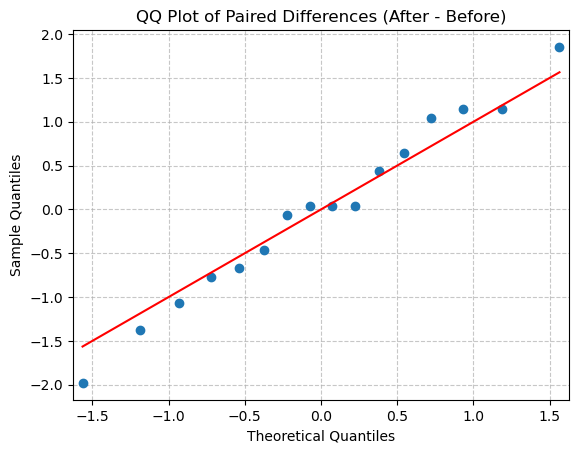

In [74]:
diff = B - A
plt.figure(figsize=(8, 5))
sm.qqplot(diff, line='s', fit=True)
plt.title("QQ Plot of Paired Differences (After - Before)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This sample is a type one-sample (on differences) even though there is two sets of data, the analysis is done on the single set of differences (after and before). It is paired as the data points are linked, each "before" measurement has a corresponding "after" measurement. The test type is parametric and which assumes the underlying distribution of differences is normal.Tail one-sided (Upper tail). The hypothesis specifically asks if arsenic levels were higher after the storm.

**b) Test**

By Hand:

Paired differences

d_i = After_i − Before_i = -2.1625

Mean and standard deviation of differences

d = average(d_i)
s_d = standard deviation(d_i) = 1.0236

Standard error of mean difference

SE = s_d / sqrt(n) = 1.0236 / sqrt(16) 
= 0.2559

t statistic (one-sided)

t = d / SE = -8.45

Degrees of freedom

df = n − 1

=16-1

=15

Critical t=2.602

Using t-table with alpha = 0.01 and df=15 one-sided test: p-value = <0.0005: reject null hypothesis

By Python:

In [75]:
d_bar = diff.mean()             
s_d = diff.std(ddof=1)           
n = len(diff)                    
se = s_d / np.sqrt(n)            
t_stat = d_bar / se              
df = n - 1                       

p_value = stats.t.sf(t_stat, df) 
t_crit = stats.t.ppf(1 - 0.01, df) 

print(f"T-statistic: {t_stat}")
print(f"Critical T: {t_crit}")
print(f"P-value: {p_value}")

T-statistic: 8.450258654134498
Critical T: 2.602480294995493
P-value: 2.1796152651556397e-07


The statistical test confirms with high confidence (p < 0.01) that arsenic levels in the  collection tanks increased significantly following the storm.

**c) CI**

By Hand:

99% Confidence Interval for mean change: 2-sided

=d_i ± t_(0.995, df) * SE

=2.1625 ± (2.977)(0.2559)

=[ 2.916, 1.400]

By Python:

In [76]:
alpha = 0.01
t_crit = stats.t.ppf(1 - alpha/2, df)

margin_of_error = t_crit * se

lower_bound = d_bar - margin_of_error
upper_bound = d_bar + margin_of_error

print(f"Mean Difference (d_bar):{d_bar}")
print(f"T-critical (0.995, 15):{t_crit}")
print(f"Margin of Error:{margin_of_error}")
print(f"99% CI Lower Bound:{lower_bound}")
print(f"99% CI Upper Bound:{upper_bound}")

Mean Difference (d_bar):2.1625
T-critical (0.995, 15):2.9467128834859504
Margin of Error:0.7540913090773357
99% CI Lower Bound:1.4084086909226645
99% CI Upper Bound:2.9165913090773357


Interpretation: We are 99% confident that the true average increase in arsenic levels across all similar tanks following a storm is between 1.41 ppb and 2.92 ppb

**d) Ignoring Pairing: Welch Two-Sample T-test**

In [80]:
res_unpaired = stats.ttest_ind(B, A, equal_var=False, alternative='greater')

mean_diff = A.mean() - B.mean()
se_unpaired = np.sqrt(B.var(ddof=1)/len(B) + A.var(ddof=1)/len(A))

df_welch = 29.8 
t_crit_unpaired = stats.t.ppf(1 - 0.01/2, df_welch)

lower = mean_diff - t_crit_unpaired * se_unpaired
upper = mean_diff + t_crit_unpaired * se_unpaired

print(f"Unpaired P-value: {res_unpaired.pvalue:.4f}")
print(f"Unpaired 99% CI: [{lower:.4f}, {upper:.4f}]")

Unpaired P-value: 0.2773
Unpaired 99% CI: [-12.1159, 7.7909]


The reason why ignoring pairing loses power as observed from the CI width for the unpaired test is over 13 times wider than the paired version. The paired CI is very precise (1.4 to 2.9), whereas the unpaired CI is so wide that it includes zero and even negative values. The P-value has also jumped to 0.2773 from 2.1796152651556397e-07 which effects the standard error of the mean.